# Deep Q-Network (DQN) for Lunar Lander

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.5.1+cu121
CUDA: True


## 1. Install Dependencies

In [2]:
!pip install gymnasium
!pip install "gymnasium[atari, accept-rom-license]"
!apt-get install -y swig
!pip install gymnasium[box2d]


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
"apt-get" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [3]:
import os
import random
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import imageio
import matplotlib.pyplot as plt
import timeit


## 3. Set Random Seeds for Reproducibility

In [4]:
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 4. Random Action Baseline Simulation

Function to run a baseline simulation of the Lunar Lander environment using completely random actions.
Since the agent selects actions randomly, it does not learn from previous states or rewards, which usually leads to poor performance with scores around -200 to -300.

Recording the frames into a video provides a qualitative analysis tool, allowing visual comparison between an untrained agent and future RL-trained agents. This helps demonstrate the effectiveness of reinforcement learning algorithms in sequential decision-making tasks such as Lunar Lander.


In [5]:
def run_randomaction_Sim():
    """
    Function to have a game simulation of Lunar Lander with random actions
    
    Args:
    None
    """
    print("Running Game simulation with Random Action")
    env = gym.make('LunarLander-v3', render_mode="rgb_array")
    frames = []
    env.action_space.seed(seed_value)
    state, info = env.reset(seed=seed_value)
    done = False
    score = 0
    n_step = 0
    
    while not done:
        frame = env.render()
        frames.append(frame)
        n_step += 1
        action = env.action_space.sample()  # Take random action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        score += reward
    
    print(f"Random agent total score = {score:.2f} done in {n_step} steps")
    env.close()
    
    # Save frames as video
    with imageio.get_writer("lunarlander_RandomActionsSim.mp4", fps=30) as writer:
        for frame in frames:
            writer.append_data(frame)
    print("Random Action video Sim saved")

In [6]:
run_randomaction_Sim()

Running Game simulation with Random Action
Random agent total score = -351.16 done in 123 steps


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Random Action video Sim saved


## 5. Neural Network and Replay Memory

Layer normalization was incorporated after each fully connected layer to stabilize the learning process. Environments such as Lunar Lander, state distributions and target Q-values can vary significantly during training. Layer normalization mitigates internal covariate shift by normalizing activations, improving gradient stability, accelerating convergence, and reducing training oscillations. Unlike Batch Normalization, LayerNorm operates independently of batch statistics, making it more suitable for replay-buffer-based DQN training.

In [7]:
class Network(nn.Module):
    """Deep Q-Network with improved architecture"""
    
    def __init__(self, state_size, action_size, seed=seed_value):
        super(Network, self).__init__()
        self.seed = torch.manual_seed(seed)
        
        # Baseline architecture
        self.fc1 = nn.Linear(state_size, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, action_size)
        
        # Layer normalization for stable training
        self.ln1 = nn.LayerNorm(256)
        self.ln2 = nn.LayerNorm(256)
        self.ln3 = nn.LayerNorm(128)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.1)
        
        # Initialize weights using He initialization (better for ReLU)
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
            module.bias.data.fill_(0.01)
    
    def forward(self, state):
        x = F.relu(self.ln1(self.fc1(state)))
        x = self.dropout(x)
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.ln3(self.fc3(x)))
        return self.fc4(x)


class ReplayMemory(object):
    """Replay buffer to store and sample experiences"""
    
    def __init__(self, capacity, seed=seed_value):
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.capacity = capacity
        self.memory = []
        self.position = 0
        random.seed(seed)
    
    def push(self, event):
        """Save an experience in the replay buffer"""
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = event
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size):
        """Sample a batch of experiences from the replay buffer"""
        experiences = random.sample(self.memory, k=batch_size)
        
        states = torch.from_numpy(
            np.vstack([e[0] for e in experiences if e is not None])
        ).float().to(self.device)
        
        actions = torch.from_numpy(
            np.vstack([e[1] for e in experiences if e is not None])
        ).long().to(self.device)
        
        rewards = torch.from_numpy(
            np.vstack([e[2] for e in experiences if e is not None])
        ).float().to(self.device)
        
        next_states = torch.from_numpy(
            np.vstack([e[3] for e in experiences if e is not None])
        ).float().to(self.device)
        
        dones = torch.from_numpy(
            np.vstack([e[4] for e in experiences if e is not None]).astype(np.uint8)
        ).float().to(self.device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.memory)

## 6. Visualization Functions

In [8]:
def plot_rewards(rewards, save_path='rewards_plot.png', window_size=100):
    """
    Plots the rewards vs Episode graph along with moving average.
    
    Args:
    - rewards (list): List of rewards for each episode.
    - save_path (str): Path to save the plot
    - window_size (int): Window size for moving average
    """
    plt.figure(figsize=(12, 6))
    episodes = range(1, len(rewards) + 1)
    
    plt.plot(episodes, rewards, alpha=0.3, color='blue', label='Reward per Episode')
    
    # Moving Average
    if len(rewards) >= window_size:
        moving_avg_rewards = [
            np.mean(rewards[max(0, i-window_size):i]) 
            for i in range(1, len(rewards) + 1)
        ]
        plt.plot(episodes, moving_avg_rewards, color='red', linewidth=2,
                label=f'Moving Average (window={window_size})')
    
    # Add target line
    plt.axhline(y=200, color='green', linestyle='--', linewidth=2, 
                label='Target Score (200)', alpha=0.7)
    
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Reward', fontsize=12)
    plt.title('Training Progress: Reward per Episode', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Rewards plot saved to {save_path}")


def plot_losses(losses, save_path='losses_plot.png', window_size=100):
    """
    Plots the losses vs update step graph along with moving average.
    
    Args:
    - losses (list): List of losses for each update step.
    - save_path (str): Path to save the plot
    - window_size (int): Window size for moving average
    """
    plt.figure(figsize=(12, 6))
    step_indices = range(1, len(losses) + 1)
    
    plt.plot(step_indices, losses, alpha=0.3, color='green', label='Loss per Update Step')
    
    # Moving Average
    if len(losses) >= window_size:
        moving_avg_losses = [
            np.mean(losses[max(0, i-window_size):i]) 
            for i in range(1, len(losses) + 1)
        ]
        plt.plot(step_indices, moving_avg_losses, color='purple', linewidth=2,
                label=f'Moving Average (window={window_size})')
    
    plt.xlabel('Update Step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Progress: Loss Over Time', fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Loss plot saved to {save_path}")

## 7. DQN Agent Implementation

In [9]:
class Agent():
    """DQN Agent with Double DQN and improved hyperparameters"""
    
    def __init__(self, state_size, action_size, seed=seed_value):
        """
        Initialize an Agent object and its hyperparameters
        
        Args:
        - state_size (int): Dimension of each state
        - action_size (int): Number of possible actions
        - seed (int): Random seed
        """
        # Hyperparameters
        self.learning_rate = 5e-4  # Slightly lower learning rate
        self.batch_size = 128
        self.gamma = 0.99  # Discount factor
        self.tau = 1e-3  # Soft update parameter
        self.update_every = 4  # More frequent updates
        self.update_target_every = 100  # Hard update target network periodically
        
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        
        self.state_size = state_size
        self.action_size = action_size
        self.seed = seed
        random.seed(seed)
        
        # Initialize local and target Q networks
        self.local_qnetwork = Network(state_size, action_size, seed).to(self.device)
        self.target_qnetwork = Network(state_size, action_size, seed).to(self.device)
        
        # Copy weights from local to target network
        self.hard_update(self.local_qnetwork, self.target_qnetwork)
        
        # Optimizer with weight decay for regularization
        self.optimizer = optim.AdamW(
            self.local_qnetwork.parameters(), 
            lr=self.learning_rate,
            weight_decay=1e-5
        )
        
        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, 
            step_size=200, 
            gamma=0.9
        )
        
        # Replay memory
        self.memory = ReplayMemory(int(1e5), seed)
        self.t_step = 0
        self.episode_count = 0
        
        # Track losses
        self.losses = []
    
    def step(self, state, action, reward, next_state, done):
        """
        Store experiences in replay memory and trigger learning
        
        Args:
        - state (array_like): Current state
        - action (int): Action taken
        - reward (float): Reward received
        - next_state (array_like): Next state
        - done (bool): Whether the episode is done/finished
        
        Returns:
        - loss value (float or None)
        """
        # Store experience in replay memory
        self.memory.push((state, action, reward, next_state, done))
        
        # Learn every update_every steps
        self.t_step = (self.t_step + 1) % self.update_every
        if self.t_step == 0 and len(self.memory) > self.batch_size:
            experiences = self.memory.sample(self.batch_size)
            loss = self.learn(experiences)
            return loss
        return None
    
    def act(self, state, epsilon=0.):
        """
        Select action using epsilon-greedy policy
        
        Args:
        - state (array_like): Current state
        - epsilon (float): Exploration rate
        
        Returns:
        - action (int): Selected action
        """
        state = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        
        self.local_qnetwork.eval()
        with torch.no_grad():
            action_values = self.local_qnetwork(state)
        self.local_qnetwork.train()
        
        # Epsilon-greedy action selection
        if random.random() > epsilon:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))
    
    def learn(self, experiences):
        """
        Update network parameters using Double DQN algorithm
        
        Args:
        - experiences (tuple): Tuple of (states, actions, rewards, next_states, dones)
        
        Returns:
        - loss_value (float): Loss value for this update
        """
        states, actions, rewards, next_states, dones = experiences
        
        # Double DQN: Use local network to select actions, target network to evaluate
        with torch.no_grad():
            # Get best actions from local network
            local_next_actions = self.local_qnetwork(next_states).argmax(1, keepdim=True)
            # Evaluate those actions with target network
            next_q_values = self.target_qnetwork(next_states).gather(1, local_next_actions)
            # Compute target Q values
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))
        
        # Get expected Q values from local network
        expected_q_values = self.local_qnetwork(states).gather(1, actions)
        
        # Compute Huber loss (more robust than MSE)
        loss = F.smooth_l1_loss(expected_q_values, target_q_values)
        
        # Store loss for plotting
        loss_value = loss.item()
        self.losses.append(loss_value)
        
        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.local_qnetwork.parameters(), 1.0)
        
        self.optimizer.step()
        
        # Soft update target network
        self.soft_update(self.local_qnetwork, self.target_qnetwork, self.tau)
        
        return loss_value
    
    def soft_update(self, local_model, target_model, tau):
        """
        Soft update target network parameters:
        θ_target = τ*θ_local + (1 - τ)*θ_target
        
        Args:
        - local_model (torch.nn.Module): Local model
        - target_model (torch.nn.Module): Target model
        - tau (float): Interpolation parameter
        """
        for target_param, local_param in zip(target_model.parameters(), 
                                            local_model.parameters()):
            target_param.data.copy_(
                tau * local_param.data + (1.0 - tau) * target_param.data
            )
    
    def hard_update(self, local_model, target_model):
        """
        Hard update: copy weights from local to target network
        
        Args:
        - local_model (torch.nn.Module): Local model
        - target_model (torch.nn.Module): Target model
        """
        target_model.load_state_dict(local_model.state_dict())
    
    def end_episode(self):
        """Called at the end of each episode"""
        self.episode_count += 1
        self.scheduler.step()
        
        # Periodic hard update of target network
        if self.episode_count % self.update_target_every == 0:
            self.hard_update(self.local_qnetwork, self.target_qnetwork)
            print(f"\nHard update of target network at episode {self.episode_count}")

## 8. Training Function

In [10]:
def train_agent(env_name="LunarLander-v3", num_episodes=2000, max_steps=1000, 
                target_score=200.0):
    """
    Train the DQN agent
    
    Args:
    - env_name (str): Name of the environment
    - num_episodes (int): Number of episodes to train for
    - max_steps (int): Maximum number of steps per episode
    - target_score (float): Target average score for solving the environment
    
    Returns:
    - agent: Trained agent
    - scores: List of scores per episode
    - losses: List of losses during training
    """
    # Create environment
    env = gym.make(env_name)
    env.action_space.seed(seed_value)
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    
    print(f"Environment: {env_name}")
    print(f"State size: {state_size}")
    print(f"Action size: {action_size}")
    
    action_meanings = {
        0: "Do nothing",
        1: "Fire left orientation engine",
        2: "Fire main engine (move up)",
        3: "Fire right orientation engine"
    }
    
    print("\nAction meanings:")
    for action, meaning in action_meanings.items():
        print(f"  {action}: {meaning}")
    
    # Initialize agent
    agent = Agent(state_size, action_size)
    
    # Epsilon decay parameters - improved schedule
    epsilon_start = 1.0
    epsilon_end = 0.01
    epsilon_decay = 0.996  # Slightly faster decay
    epsilon = epsilon_start
    
    scores = []
    scores_window = deque(maxlen=100)
    best_avg_score = -float('inf')
    
    print(f"\n{'='*60}")
    print("Starting Training")
    print(f"{'='*60}\n")
    start_time = timeit.default_timer()
    
    for episode in range(1, num_episodes + 1):
        episode_seed = seed_value + episode
        state, _ = env.reset(seed=episode_seed)
        score = 0
        
        for t in range(max_steps):
            # Select and perform action
            action = agent.act(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store experience and learn
            agent.step(state, action, reward, next_state, done)
            
            state = next_state
            score += reward
            
            if done:
                break
        
        # End of episode
        agent.end_episode()
        scores_window.append(score)
        scores.append(score)
        epsilon = max(epsilon_end, epsilon_decay * epsilon)
        
        # Calculate average score
        avg_score = np.mean(scores_window)
        
        # Print progress
        print(f'\rEpisode {episode:4d}\tAvg: {avg_score:7.2f}\tScore: {score:7.2f}\tε: {epsilon:.4f}', 
              end="")
        
        if episode % 100 == 0:
            elapsed_time = timeit.default_timer() - start_time
            print(f'\rEpisode {episode:4d}\tAverage Score: {avg_score:.2f}\t'
                  f'Time: {elapsed_time:.1f}s')
        
        # Save best model
        if avg_score > best_avg_score:
            best_avg_score = avg_score
            torch.save(agent.local_qnetwork.state_dict(), 'checkpoint_best.pth')
        
        # Check if solved
        if avg_score >= target_score:
            elapsed_time = timeit.default_timer() - start_time
            print(f'\n{"="*60}')
            print(f'Environment solved in {episode} episodes!')
            print(f'Average Score: {avg_score:.2f}')
            print(f'Training Time: {elapsed_time:.1f} seconds')
            print(f'{"="*60}')
            break
    
    # Training completed
    end_time = timeit.default_timer()
    total_time = end_time - start_time
    
    print(f'\n{"="*60}')
    print(f'Training Completed')
    print(f'Final Average Score: {np.mean(scores_window):.2f}')
    print(f'Best Average Score: {best_avg_score:.2f}')
    print(f'Total Training Time: {total_time:.1f} seconds')
    print(f'{"="*60}')
    
    # Save final model
    torch.save(agent.local_qnetwork.state_dict(), 'checkpoint_final.pth')
    print("Models saved: checkpoint_best.pth and checkpoint_final.pth")
    
    env.close()
    return agent, scores, agent.losses

## 9. Video Generation Function

In [11]:
def generate_video(agent, env_name="LunarLander-v3", 
                  video_file="lunar_lander_landing.mp4", num_attempts=10):
    """
    Generate video of the trained agent's best performance
    
    Args:
    - agent (Agent): Trained agent
    - env_name (str): Name of the environment
    - video_file (str): Name of the video file to save
    - num_attempts (int): Number of attempts to find best performance
    """
    env = gym.make(env_name, render_mode='rgb_array')
    
    best_reward = -float('inf')
    best_frames = []
    all_rewards = []
    
    print(f"\nGenerating video from {num_attempts} attempts...")
    
    for attempt in range(num_attempts):
        state, _ = env.reset(seed=seed_value + attempt + 1000)
        frames = []
        total_reward = 0
        done = False
        steps = 0
        
        while not done:
            frame = env.render()
            frames.append(frame)
            
            # Use greedy action (no exploration)
            action = agent.act(state, epsilon=0.0)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            state = next_state
            total_reward += reward
            steps += 1
        
        all_rewards.append(total_reward)
        print(f"Attempt {attempt+1:2d}/{num_attempts}: "
              f"Score = {total_reward:7.2f}, Steps = {steps:3d}")
        
        # Keep best attempt
        if total_reward > best_reward and len(frames) > 0:
            best_reward = total_reward
            best_frames = frames
    
    env.close()
    
    # Save video
    if len(best_frames) > 0:
        print(f"\nBest performance:")
        print(f"  Score: {best_reward:.2f}")
        print(f"  Average score: {np.mean(all_rewards):.2f}")
        print(f"  Frames: {len(best_frames)}")
        print(f"\nSaving video to {video_file}...")
        imageio.mimsave(video_file, best_frames, fps=30)
        print(f"Video saved successfully!")
    else:
        print("Warning: Could not generate any frames for video.")

## 10. Main Training Loop

Starting DQN Training for Lunar Lander

Environment: LunarLander-v3
State size: 8
Action size: 4

Action meanings:
  0: Do nothing
  1: Fire left orientation engine
  2: Fire main engine (move up)
  3: Fire right orientation engine
Using device: cuda:0

Starting Training



D:\2026-1\Deep Learning\finalProject\Project\CartPoleRL-Ablation\lunar_lander_env\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Episode   99	Avg: -125.80	Score: -187.77	ε: 0.6725
Hard update of target network at episode 100
Episode  100	Average Score: -125.65	Time: 29.4s698
Episode  199	Avg:  -53.02	Score:   88.62	ε: 0.4504
Hard update of target network at episode 200
Episode  200	Average Score: -51.95	Time: 86.1s4486
Episode  299	Avg:   39.67	Score:  105.33	ε: 0.3017
Hard update of target network at episode 300
Episode  300	Average Score: 40.66	Time: 271.3s3005
Episode  399	Avg:  110.90	Score:  130.78	ε: 0.2021
Hard update of target network at episode 400
Episode  400	Average Score: 112.63	Time: 481.2s012
Episode  471	Avg:  201.37	Score:  257.81	ε: 0.1514
Environment solved in 471 episodes!
Average Score: 201.37
Training Time: 604.9 seconds

Training Completed
Final Average Score: 201.37
Best Average Score: 201.37
Total Training Time: 604.9 seconds
Models saved: checkpoint_best.pth and checkpoint_final.pth

Generating training plots...


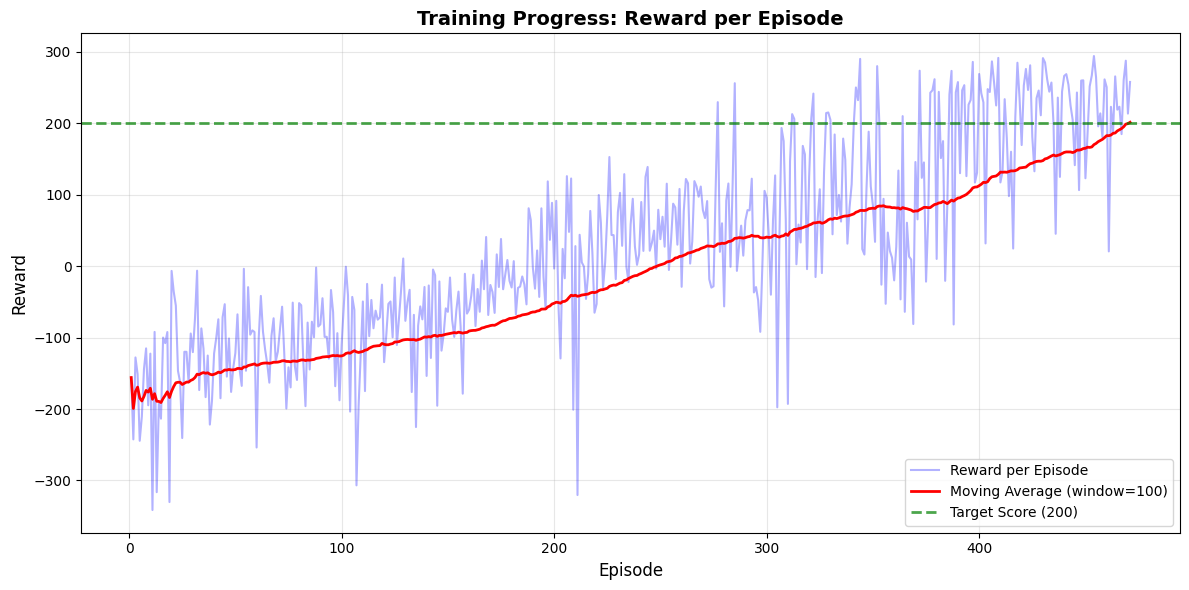

Rewards plot saved to training_rewards_graph.png


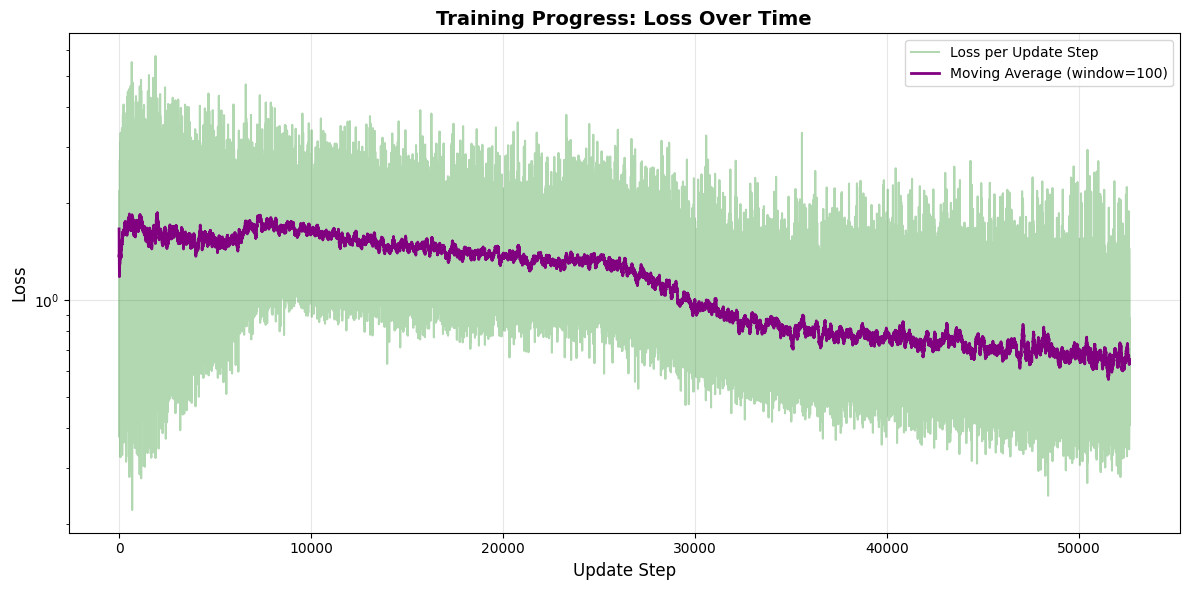

Loss plot saved to training_loss_graph.png

Running random action baseline...
Running Game simulation with Random Action


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Random agent total score = -351.16 done in 123 steps
Random Action video Sim saved

Generating video of trained agent...

Generating video from 10 attempts...
Attempt  1/10: Score =   -9.42, Steps = 1000
Attempt  2/10: Score =  174.43, Steps = 431
Attempt  3/10: Score =  114.98, Steps = 698
Attempt  4/10: Score =  300.53, Steps = 307
Attempt  5/10: Score =  244.52, Steps = 237
Attempt  6/10: Score =  185.45, Steps = 766
Attempt  7/10: Score =    0.84, Steps = 1000
Attempt  8/10: Score =  189.80, Steps = 464
Attempt  9/10: Score =  234.98, Steps = 326


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Attempt 10/10: Score =  287.11, Steps = 318

Best performance:
  Score: 300.53
  Average score: 172.32
  Frames: 307

Saving video to lunarlander_TrainedSim.mp4...
Video saved successfully!

Training and evaluation complete!


In [12]:
if __name__ == "__main__":
    # Train the agent
    print("Starting DQN Training for Lunar Lander\n")
    agent, rewards, losses = train_agent(num_episodes=2000, target_score=200.0)
    
    # Plot training results
    print("\nGenerating training plots...")
    plot_rewards(rewards, save_path='training_rewards_graph.png')
    plot_losses(losses, save_path='training_loss_graph.png')
    
    # Run random action baseline
    print("\nRunning random action baseline...")
    run_randomaction_Sim()
    
    # Generate video of trained agent
    print("\nGenerating video of trained agent...")
    generate_video(agent, video_file="lunarlander_TrainedSim.mp4", num_attempts=10)
    
    print("\n" + "="*60)
    print("Training and evaluation complete!")
    print("="*60)